# Bivariate BMM Test

### Author: Alexandra Semposki

### Date: 10 September 2023

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib 
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
%matplotlib inline

In [2]:
import sys
sys.path.append('../../../')

In [3]:
from Taweret.models.samba_models import *
from Taweret.mix.gaussian import *

In [4]:
g = np.linspace(1e-6, 1.0, 100)
order = 3

In [5]:
model_1 = Loworder(order)
model_2 = Highorder(order)
true = TrueModel().evaluate(g)

exp_1 = model_1.evaluate(g)
exp_2 = model_2.evaluate(g)

var_1 = exp_1[1].flatten()
var_2 = exp_2[1].flatten()

# combine to form dict of models
models = {
    '1': model_1,
    '2': model_2
}

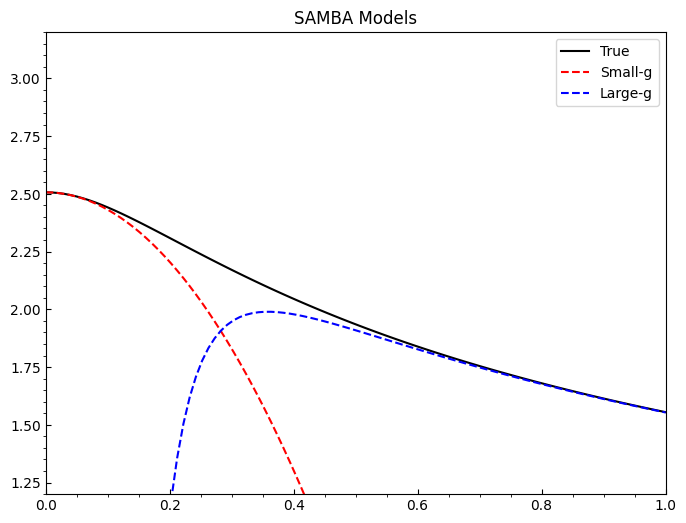

In [6]:
#example plot to test models
fig = plt.figure(figsize=(8,6), dpi=100)
ax = plt.axes()
ax.set_xlim(0.0,1.0)
ax.set_ylim(1.2,3.2)
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='y', direction='in')
ax.locator_params(nbins=8)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

ax.plot(g, true[0].flatten(), 'k', label='True')
ax.plot(g, exp_1[0].flatten(), 'r--', label='Small-g')
ax.plot(g, exp_2[0].flatten(), 'b--', label='Large-g')

ax.set_title('SAMBA Models')
ax.legend()

In [21]:
# define correlation parameter
R = -0.99

#call mixing method and plot
mixed = Multivariate(g, models, n_models=2)
_, mixed_mean, mixed_intervals, mixed_std_dev = mixed.predict(ci=68,correlated=True,R=R,S=0,T=0)

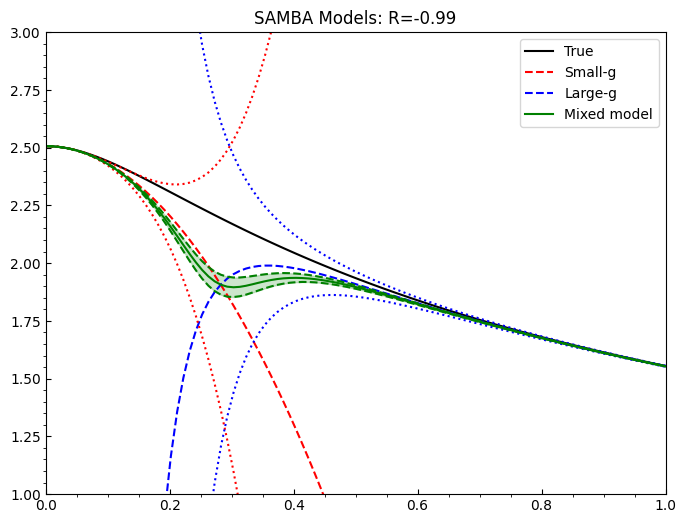

In [22]:
#plotting bivariate BMM results on top of SAMBA models
fig = plt.figure(figsize=(8,6), dpi=100)
ax = plt.axes()
ax.set_xlim(0.0,1.0)
ax.set_ylim(1.0,3.0)
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='y', direction='in')
ax.locator_params(nbins=8)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

ax.plot(g, true[0].flatten(), 'k', label='True')
ax.plot(g, exp_1[0].flatten(), 'r--', label='Small-g')
ax.plot(g, exp_2[0].flatten(), 'b--', label='Large-g')

ax.plot(g, exp_1[0].flatten() - var_1, 'r', linestyle='dotted')
ax.plot(g, exp_1[0].flatten() + var_1, 'r', linestyle='dotted')

ax.plot(g, exp_2[0].flatten() - var_2, 'b', linestyle='dotted')
ax.plot(g, exp_2[0].flatten() + var_2, 'b', linestyle='dotted')

ax.plot(g, mixed_mean, 'g', label='Mixed model')
ax.plot(g, mixed_intervals[0][0], 'g--')
ax.plot(g, mixed_intervals[1][0], 'g--')
ax.fill_between(g, mixed_intervals[0][0], mixed_intervals[1][0], color='green', alpha=0.2)

ax.set_title('SAMBA Models: R={}'.format(R))
ax.legend()

Written by: Alexandra Semposki

Last edited: 10 September 2023